# Trabalho Prático 1 - ANADI

## 4.2 - Manipulação de dados

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import ttest_ind
import scipy.stats as stats


### 4.2.1 - Processamento da Iluminação Pública (IP_data)

In [32]:
print("\n--- 4.2.1: Processamento da Iluminação Pública ---")

# 0. Ler o ficheiro de dados
# (Ajusta o nome do ficheiro para .xlsx ou .csv conforme o que estiveres a usar no teu código)
ip = pd.read_excel("IP_data.xlsx")

# 1. Criar variável binária Is_Ineficiente
ip["Is_Ineficiente"] = ip["Tipo de Lâmpada"].isin(["Sódio", "Mercúrio"]).astype(int)

# 2. Criar variável Potência kW
# Atenção ao nome real da coluna no ficheiro: Potência Instalada Total (W)
ip["Potência kW"] = ip["Potência Instalada Total (W)"] / 1000

# Coluna auxiliar para calcular a potência ineficiente mais facilmente no groupby
ip["Potencia_Inef_Temp"] = ip["Potência kW"] * ip["Is_Ineficiente"]

# 3. Agrupar por CodDistritoConcelho
ip_group = ip.groupby("CodDistritoConcelho").agg(
    P_IP_Total=("Potência kW", "sum"),
    P_IP_Inef=("Potencia_Inef_Temp", "sum")
).reset_index()

# Opcional: Apagar a coluna temporária do dataframe original (boas práticas)
ip = ip.drop(columns=["Potencia_Inef_Temp"])

print("Resultado do agrupamento IP (Primeiras linhas):")
print(ip_group.head())


--- 4.2.1: Processamento da Iluminação Pública ---
Resultado do agrupamento IP (Primeiras linhas):
   CodDistritoConcelho   P_IP_Total  P_IP_Inef
0                  101   910.887701    244.320
1                  102   451.711801     28.020
2                  103   657.071801     73.545
3                  104   585.974400    115.720
4                  105  1055.192001    144.420


### 4.2.2 - Processamento dos Postos de Transformação (PTD_data)

No ficheiro PTD, o nível de utilização dos postos de transformação encontrava-se representado em
intervalos percentuais (ex.: 60%-79%). Para efeitos de análise quantitativa, foi considerado o limite superior do intervalo, convertendo os valores para formato decimal (ex.: 0.79). Valores representados como intervalos percentuais foram convertidos considerando o limite superior do intervalo. Valores indicados como "<20" foram aproximados para 0.20 e valores "N/D" foram tratados como dados omissos.

Por fim, agrupou-se por concelho os dados do ficheiro PTDA para obter 3 dados importantes para cálculos futuros: soma da potência instalada de todos os PTDs do concelho, média do Nível de Utilização de todos os PTDs do concelho, número de PTDs de cada concelho.


In [33]:
def converter_utilizacao(valor):

    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    # casos tipo "60%-79%"
    if "-" in valor and "%" in valor:
        return float(valor.split("-")[1].replace("%", "")) / 100

    # caso "+100%"
    if "+" in valor:
        return 1.0

    # caso "<20"
    if "<" in valor:
        return 0.20

    # caso "N/D"
    if "N/D" in valor:
        return np.nan

    return np.nan

ptd = pd.read_excel("PTD_data.xlsx")

ptd["Utilizacao_decimal"] = ptd["Nível de Utilização [%]"].apply(converter_utilizacao)

print("4.2.2: Conversão de nível de utilização para decimal:")
print(ptd[["Nível de Utilização [%]", "Utilizacao_decimal"]].head())

ptd_group = ptd.groupby("CodDistritoConcelho").agg(

    Cap_PTD=("Potência instalada [kVA]", "sum"),

    Util_Media=("Utilizacao_decimal", "mean"),

    N_PTDs=("Código de Instalação", "count")

).reset_index()

print()
print("4.2.2: Agrupar por Código Distrito Concelho")
print(ptd_group.head())

4.2.2: Conversão de nível de utilização para decimal:
  Nível de Utilização [%]  Utilizacao_decimal
0                 60%-79%                0.79
1                 60%-79%                0.79
2                 60%-79%                0.79
3                   +100%                1.00
4                  0%-19%                0.19

4.2.2: Agrupar por Código Distrito Concelho
   CodDistritoConcelho  Cap_PTD  Util_Media  N_PTDs
0                  101   105715    0.477593     388
1                  102    54540    0.469948     194
2                  103    55628    0.543009     223
3                  104    41884    0.527387     236
4                  105   197485    0.475475     509


### 4.2.3 - Variáveis do Novo Dataset

In [34]:
df_final = pd.merge(ip_group, ptd_group, on="CodDistritoConcelho", how="inner")

df_final["Delta_PLED"] = df_final["P_IP_Inef"] * 0.65
df_final["PFolga"] = (df_final["Cap_PTD"] * 0.92) * (1 - df_final["Util_Media"])
df_final["PVE"] = df_final["N_PTDs"] * 22 * 0.60
df_final["D"] = df_final["PFolga"] + df_final["Delta_PLED"] - df_final["PVE"]
df_final["Rate_Ineficiencia"] = df_final["P_IP_Inef"] / df_final["P_IP_Total"]

# criar tabela com nomes mais intuitivos
tabela_resumo = df_final[[
    "CodDistritoConcelho",
    "P_IP_Total",
    "P_IP_Inef",
    "Cap_PTD",
    "Util_Media",
    "N_PTDs",
    "Delta_PLED",
    "PFolga",
    "PVE",
    "D",
    "Rate_Ineficiencia"
]].copy()

# renomear colunas para o relatório
tabela_resumo.columns = [
    "CodDistritoConcelho",
    "P_IP_Total (kW)",
    "P_IP_Inef (kW)",
    "Capacidade PTD (kVA)",
    "Utilização Média",
    "Nº PTDs",
    "Ganho LED (kW)",
    "Folga Rede (kW)",
    "Carga VE (kW)",
    "Saldo Final D (kW)",
    "Taxa Ineficiência"
]

# arredondar valores para ficar mais apresentável
tabela_resumo = tabela_resumo.round(4)

# mostrar apenas 10 concelhos
pd.set_option('display.max_columns', None)
print("\n--- 4.2.3: Tabela resumo (10 concelhos) ---")
print(tabela_resumo.head(10))


--- 4.2.3: Tabela resumo (10 concelhos) ---
   CodDistritoConcelho  P_IP_Total (kW)  P_IP_Inef (kW)  Capacidade PTD (kVA)  \
0                  101         910.8877         244.320                105715   
1                  102         451.7118          28.020                 54540   
2                  103         657.0718          73.545                 55628   
3                  104         585.9744         115.720                 41884   
4                  105        1055.1920         144.420                197485   
5                  106         391.7101         137.900                 25760   
6                  107         387.5047          49.295                 62765   
7                  108         468.5167          38.215                 52200   
8                  109        2045.0107         757.570                223550   
9                  110         472.9127         102.015                 79890   

   Utilização Média  Nº PTDs  Ganho LED (kW)  Folga Rede (kW)  

## 4.3 - Análise e Exploração de dados

### 4.3.1 - Mix tecnológico (LED vs Convencional)


--- 4.3.1: Mix tecnológico da iluminação pública ---
Potência total por tecnologia:
Tecnologia
Convencional (Sódio/Mercúrio)     61708.65900
LED / Outras eficientes          118799.21451
Name: Potência kW, dtype: float64


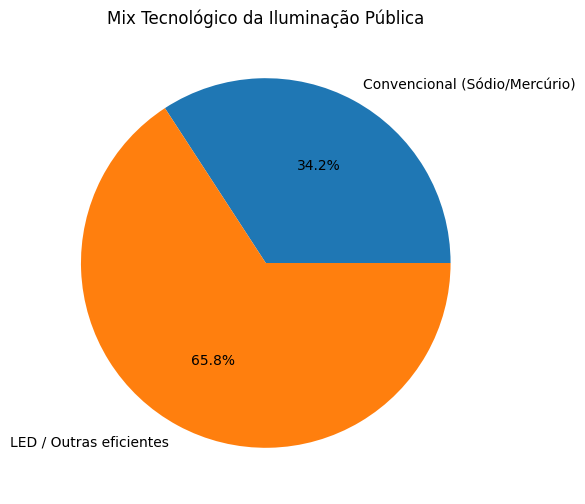


Concelhos com maior potência ineficiente:
     CodDistritoConcelho  P_IP_Inef
151                 1105   3494.920
157                 1111   2764.985
156                 1110   2757.620
185                 1308   2509.780
219                 1503   2464.555
61                   503   1807.900
72                   603   1714.755
183                 1306   1530.430
108                  808   1518.075
190                 1313   1513.920


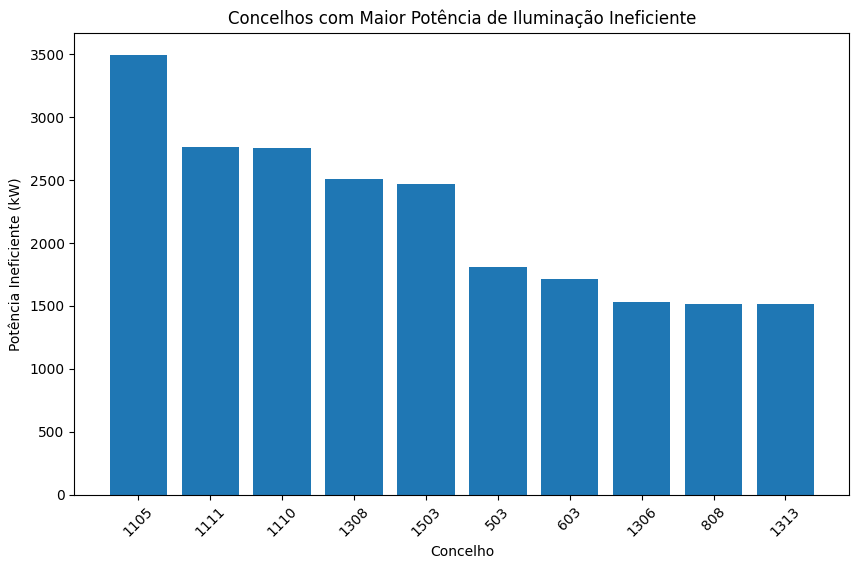

In [35]:
print("\n--- 4.3.1: Mix tecnológico da iluminação pública ---")

# classificar tecnologia
ip["Tecnologia"] = ip["Is_Ineficiente"].map({
    1: "Convencional (Sódio/Mercúrio)",
    0: "LED / Outras eficientes"
})

# somar potência por tecnologia
mix_tecnologico = ip.groupby("Tecnologia")["Potência kW"].sum()

print("Potência total por tecnologia:")
print(mix_tecnologico)

# gráfico pie
plt.figure(figsize=(6,6))
mix_tecnologico.plot(kind="pie", autopct="%1.1f%%")

plt.title("Mix Tecnológico da Iluminação Pública")
plt.ylabel("")

plt.show()


# verificar concentração da potência ineficiente por município
top_ineficientes = ip_group.sort_values("P_IP_Inef", ascending=False).head(10)

print()
print("Concelhos com maior potência ineficiente:")
print(top_ineficientes[["CodDistritoConcelho", "P_IP_Inef"]])

plt.figure(figsize=(10,6))
plt.bar(top_ineficientes["CodDistritoConcelho"].astype(str), top_ineficientes["P_IP_Inef"])

plt.title("Concelhos com Maior Potência de Iluminação Ineficiente")
plt.xlabel("Concelho")
plt.ylabel("Potência Ineficiente (kW)")

plt.xticks(rotation=45)

plt.show()

### 4.3.2 - Boxplots por Distrito


--- 4.3.2: Boxplots de Utilização por Distrito ---


<Figure size 1000x600 with 0 Axes>

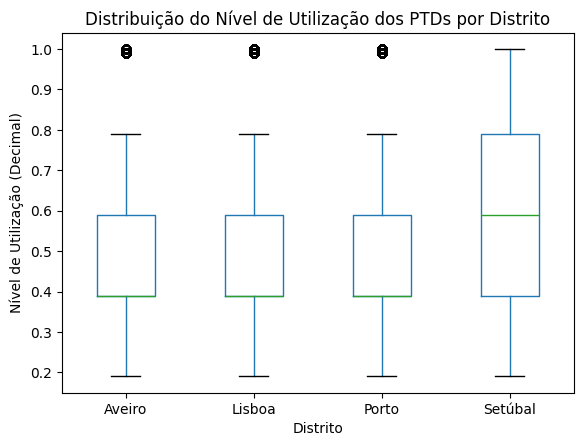

Variabilidade (Desvio Padrão) da utilização por distrito:
Distrito
Setúbal    0.254050
Lisboa     0.242931
Porto      0.239539
Aveiro     0.237937
Name: Utilizacao_decimal, dtype: float64


In [36]:
print("\n--- 4.3.2: Boxplots de Utilização por Distrito ---")

# 1. Extrair o código do Distrito (os primeiros dígitos do CodDistritoConcelho)
# Como o CodDistritoConcelho tem 3 ou 4 dígitos, uma divisão inteira por 100 dá-nos o Distrito.
ptd["CodDistrito"] = ptd["CodDistritoConcelho"] // 100

# 2. Mapear o código para o nome do Distrito correspondente
mapa_distritos = {
    1: "Aveiro",
    11: "Lisboa",
    13: "Porto",
    15: "Setúbal"
}
ptd["Distrito"] = ptd["CodDistrito"].map(mapa_distritos)

# 3. Definir os distritos que queremos analisar e remover valores nulos
distritos_alvo = ["Lisboa", "Porto", "Aveiro", "Setúbal"]
ptd_filtrado = ptd[ptd["Distrito"].isin(distritos_alvo)].dropna(subset=["Utilizacao_decimal"])

# 4. Criar a caixa de bigodes (boxplot)
plt.figure(figsize=(10, 6))
ptd_filtrado.boxplot(column="Utilizacao_decimal", by="Distrito", grid=False)

# Formatar o gráfico
plt.title("Distribuição do Nível de Utilização dos PTDs por Distrito")
plt.suptitle("") # Remove o subtítulo automático
plt.xlabel("Distrito")
plt.ylabel("Nível de Utilização (Decimal)")

# Mostrar o gráfico (não te esqueças de guardar ou fazer print screen para o relatório!)
plt.show()

# 5. Calcular o desvio padrão para responder à pergunta "maior variabilidade"
variabilidade = ptd_filtrado.groupby("Distrito")["Utilizacao_decimal"].std().sort_values(ascending=False)
print("Variabilidade (Desvio Padrão) da utilização por distrito:")
print(variabilidade)

### 4.3.3 - Quantificar valores omissos ou indeterminados

Foi analisada a presença de valores omissos ou indeterminados na variável "Nível de Utilização [%]", embora outras variáveis apresentem valores "N/D" ou "<20", estas não foram consideradas na análise por não integrarem as métricas utilizadas neste estudo.

Para identificar possíveis outliers nos níveis de ocupação da rede foi utilizado um boxplot da variável convertida para formato decimal. O gráfico permitiu observar a dispersão dos dados e a presença de alguns valores extremos acima do intervalo interquartil.


4.3.3: Quantidade de valores omissos ou indeterminados:
Valores N/D: 3064
Valores <20: 0
Total de registos: 72027
Percentagem N/D: 4.25 %
Percentagem <20: 0.0 %


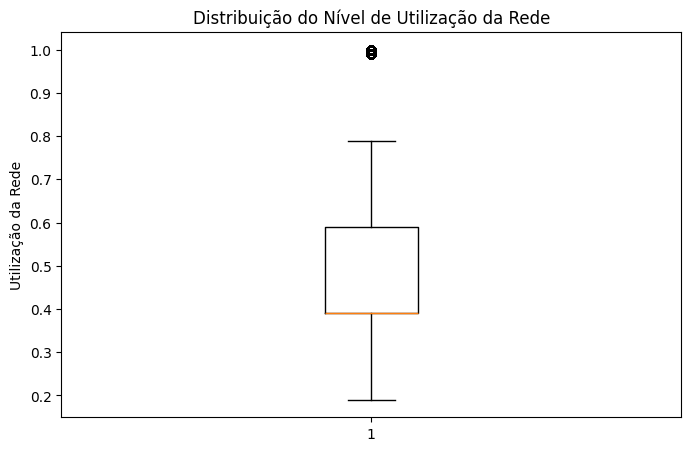

In [37]:
nd_count = (ptd["Nível de Utilização [%]"] == "N/D").sum()
lt20_count = ptd["Nível de Utilização [%]"].astype(str).str.contains("<20").sum()

total = len(ptd)

print()
print("4.3.3: Quantidade de valores omissos ou indeterminados:")
print("Valores N/D:", nd_count)
print("Valores <20:", lt20_count)
print("Total de registos:", total)

print("Percentagem N/D:", round((nd_count/total)*100,2), "%")
print("Percentagem <20:", round((lt20_count/total)*100,2), "%")

# remover NaN para análise
utilizacao = ptd["Utilizacao_decimal"].dropna()

plt.figure(figsize=(8,5))
plt.boxplot(utilizacao)

plt.title("Distribuição do Nível de Utilização da Rede")
plt.ylabel("Utilização da Rede")

plt.show()

### 4.3.4 - Estatísticas do nível de utilização para alguns concelhos

Para os concelhos de Coimbra, Évora, Braga e Faro foi construída uma tabela com estatísticas descritivas do nível médio de utilização da rede, utilizando a variável convertida para formato decimal.

Foram calculadas as seguintes medidas estatísticas: média, primeiro quartil (Q1), mediana (Q2), terceiro quartil (Q3), desvio padrão, coeficiente de assimetria e coeficiente de curtose. Estas medidas permitem caracterizar a distribuição dos níveis de utilização da rede, fornecendo informação sobre a tendência central, dispersão e forma da distribuição.

A média representa o valor médio do nível de utilização observado em cada concelho, enquanto os quartis permitem analisar a distribuição dos dados e identificar a posição relativa dos valores. O desvio padrão mede a variabilidade dos níveis de utilização em torno da média. Por sua vez, a assimetria indica se a distribuição apresenta maior concentração de valores à esquerda ou à direita da média, e a curtose permite avaliar o grau de concentração dos valores em torno da média e a presença de caudas mais ou menos acentuadas na distribuição.
Os resultados foram apresentados com quatro casas decimais, conforme solicitado no enunciado.

A análise destas estatísticas permite comparar o comportamento da utilização da rede entre os diferentes concelhos considerados.

In [38]:
concelhos = ["Coimbra", "Évora", "Braga", "Faro"]

dados_concelhos = ptd[ptd["Concelho"].isin(concelhos)]

estatisticas = dados_concelhos.groupby("Concelho")["Utilizacao_decimal"].agg([
    "mean",
    "std",
    "skew",
    pd.Series.kurt 
])

# adicionar quartis
estatisticas["Q1"] = dados_concelhos.groupby("Concelho")["Utilizacao_decimal"].quantile(0.25)
estatisticas["Q2"] = dados_concelhos.groupby("Concelho")["Utilizacao_decimal"].quantile(0.50)
estatisticas["Q3"] = dados_concelhos.groupby("Concelho")["Utilizacao_decimal"].quantile(0.75)

# reorganizar colunas
estatisticas = estatisticas[["mean", "Q1", "Q2", "Q3", "std", "skew", "kurt"]]

# arredondar para 4 casas decimais
estatisticas = estatisticas.round(4)

print()
print("4.3.4: Estatísticas do nível de utilização por concelho")
print(estatisticas)


4.3.4: Estatísticas do nível de utilização por concelho
            mean    Q1    Q2    Q3     std    skew    kurt
Concelho                                                  
Braga     0.5423  0.39  0.59  0.79  0.2401  0.4280 -0.7116
Coimbra   0.5406  0.39  0.59  0.79  0.2322  0.2258 -0.7060
Faro      0.5549  0.39  0.59  0.59  0.2126  0.3009 -0.4757
Évora     0.4546  0.19  0.39  0.59  0.2425  0.6680 -0.4254


## 4.4 - Teste de Hipóteses

### 4.4.1 - Teste ao Nível Médio de Ocupação da Rede

Neste ponto, pretende-se avaliar se o nível médio de ocupação da rede (PTDs) é estatisticamente inferior a um patamar de referência de 60% (0.60). Para isso, foi selecionada uma amostra aleatória de 50 concelhos a partir do *dataset* consolidado.

As hipóteses formuladas para este teste unilateral à esquerda são:
- **Hipótese Nula ($H_0$):** O nível de ocupação da rede é superior ou igual a 60% ($\mu \geq 0.60$).
- **Hipótese Alternativa ($H_1$):** O nível de ocupação da rede é inferior a 60% ($\mu < 0.60$).

O processo de decisão exige a verificação prévia do pressuposto de normalidade da amostra, o qual foi avaliado através do teste de Shapiro-Wilk.
Consoante o resultado deste teste de ajustamento, aplicou-se a seguinte regra de decisão (com $\alpha = 0.05$):
1. **Se a distribuição for Normal ($p > 0.05$):** Aplica-se o Teste Paramétrico *t-Student* para uma amostra, adequado para variância desconhecida.
2. **Se a distribuição não for Normal ($p \le 0.05$):** Recorre-se à alternativa não paramétrica correspondente, o Teste de Wilcoxon, cuja estatística para $n > 20$ segue uma aproximação à normal. Adicionalmente, avalia-se a simetria da distribuição através do coeficiente de *skewness*.

In [39]:
print("\n--- 4.4.1: Teste ao nível médio de ocupação da rede (< 60%) ---")

# 1. Selecionar uma amostra aleatória de 50 concelhos
amostra_50 = df_final.sample(n=50, random_state=42)
util_amostra = amostra_50["Util_Media"]

print(f"Média da amostra: {util_amostra.mean():.4f}")
print(f"Mediana da amostra: {util_amostra.median():.4f}\n")

# 2. Testar a normalidade dos dados com o teste de Shapiro-Wilk
stat_shapiro, p_shapiro = stats.shapiro(util_amostra)
print("Teste de Ajustamento (Shapiro-Wilk):")
print(f"Estatística: {stat_shapiro:.4f} | p-value: {p_shapiro:.4f}\n")

mu_0 = 0.60
alpha = 0.05

print("--- Decisão do Teste ---")
# 3. Escolher o teste mediante o resultado do Shapiro-Wilk
if p_shapiro > alpha:
    print("Como p-value > 0.05, NÃO se rejeita a normalidade dos dados.")
    print("-> Avança-se com o Teste Paramétrico: t-Student para 1 amostra.\n")

    # Teste t-Student (unilateral à esquerda)
    t_stat, p_t = stats.ttest_1samp(util_amostra, popmean=mu_0, alternative='less')

    print(f"Estatística t: {t_stat:.4f} | p-value do t-teste: {p_t:.4e}")
    if p_t < alpha:
        print("Conclusão: Rejeita-se H0. Existe evidência estatística de que o nível de ocupação é inferior a 60%.")
    else:
        print("Conclusão: Não se rejeita H0. Não existe evidência estatística de que o nível de ocupação é inferior a 60%.")

else:
    print("Como p-value <= 0.05, REJEITA-SE a normalidade dos dados.")
    print("-> Avança-se com o Teste Não Paramétrico: Teste de Wilcoxon.\n")

    # Avaliar assimetria (skewness) para o teste de Wilcoxon
    assimetria = stats.skew(util_amostra)
    print(f"Assimetria (Skewness): {assimetria:.4f}")
    if abs(assimetria) < 0.1:
        print("(Distribuição simétrica - Condição ideal para Wilcoxon cumprida)")
    elif 0.1 <= abs(assimetria) <= 1:
        print("(Distribuição moderadamente assimétrica)")
    else:
        print("(Distribuição fortemente assimétrica)")

    # Teste de Wilcoxon (unilateral à esquerda)
    w_stat, p_w = stats.wilcoxon(util_amostra - mu_0, alternative='less')

    print(f"\nEstatística W: {w_stat:.4f} | p-value do Wilcoxon: {p_w:.4e}")
    if p_w < alpha:
        print("Conclusão: Rejeita-se H0. Existe evidência estatística de que o nível de ocupação é inferior a 60%.")
    else:
        print("Conclusão: Não se rejeita H0. Não existe evidência estatística de que o nível de ocupação é inferior a 60%.")


--- 4.4.1: Teste ao nível médio de ocupação da rede (< 60%) ---
Média da amostra: 0.5063
Mediana da amostra: 0.5153

Teste de Ajustamento (Shapiro-Wilk):
Estatística: 0.9545 | p-value: 0.0523

--- Decisão do Teste ---
Como p-value > 0.05, NÃO se rejeita a normalidade dos dados.
-> Avança-se com o Teste Paramétrico: t-Student para 1 amostra.

Estatística t: -8.6663 | p-value do t-teste: 9.3175e-12
Conclusão: Rejeita-se H0. Existe evidência estatística de que o nível de ocupação é inferior a 60%.


### 4.4.2 - Teste de diferença entre concelhos Modernizados e Ineficientes

Foram selecionadas duas amostras aleatórias de 30 concelhos: uma composta por concelhos classificados como "Modernizados" (rácio de iluminação ineficiente abaixo da mediana) e outra composta por concelhos "Ineficientes" (rácio acima da mediana).

Para esta análise foram consideradas as seguintes hipóteses:

- **Hipótese nula (H₀):** O nível médio de ocupação da rede é igual entre concelhos modernizados e concelhos ineficientes.
- **Hipótese alternativa (H₁):** O nível médio de ocupação da rede difere entre concelhos modernizados e concelhos ineficientes.

A normalidade das amostras foi previamente verificada através do teste de Shapiro-Wilk, tendo-se obtido p-values superiores a 0.05 para ambos os grupos, permitindo assumir normalidade das distribuições. Assim, foi aplicado um teste t para duas amostras independentes para comparar o nível médio de ocupação da rede entre os dois grupos.

O teste resultou num p-value de 0.3071, superior ao nível de significância de 5%. Desta forma, não se rejeita a hipótese nula, concluindo-se que não existe evidência estatística suficiente para afirmar que o nível médio de ocupação da rede difere entre concelhos modernizados e concelhos ineficientes.

In [40]:
print()
print("\n--- 4.4.2: Comparação entre concelhos Modernizados e Ineficientes ---")

# calcular mediana do rácio de ineficiência
mediana = df_final["Rate_Ineficiencia"].median()

# classificar concelhos
df_final["Grupo"] = np.where(
    df_final["Rate_Ineficiencia"] > mediana,
    "Ineficiente",
    "Modernizado"
)

print("Mediana do rácio de ineficiência:", mediana)
print(df_final["Grupo"].value_counts())

modernizados = df_final[df_final["Grupo"] == "Modernizado"]
ineficientes = df_final[df_final["Grupo"] == "Ineficiente"]

amostra_mod = modernizados.sample(n=30, random_state=42)
amostra_inef = ineficientes.sample(n=30, random_state=42)

util_mod = amostra_mod["Util_Media"]
util_inef = amostra_inef["Util_Media"]

print("\nMédias das amostras:")
print("Modernizados:", util_mod.mean())
print("Ineficientes:", util_inef.mean())

shapiro_mod = shapiro(util_mod)
shapiro_inef = shapiro(util_inef)

print("\nTeste de normalidade (Shapiro-Wilk)")

print("Modernizados p-value:", shapiro_mod.pvalue)
print("Ineficientes p-value:", shapiro_inef.pvalue)

teste = ttest_ind(util_mod, util_inef)

print("\nTeste t para duas amostras independentes")
print("p-value:", teste.pvalue)



--- 4.4.2: Comparação entre concelhos Modernizados e Ineficientes ---
Mediana do rácio de ineficiência: 0.16215572702088152
Grupo
Ineficiente    139
Modernizado    139
Name: count, dtype: int64

Médias das amostras:
Modernizados: 0.5028255848155057
Ineficientes: 0.5183331710820228

Teste de normalidade (Shapiro-Wilk)
Modernizados p-value: 0.13632441131973444
Ineficientes p-value: 0.21893105150294123

Teste t para duas amostras independentes
p-value: 0.3070802286484599


4.4.3



--- 4.4.3: ANOVA entre regiões ---
Número de concelhos disponíveis por grupo:
Grupo 1: 49
Grupo 2: 48
Grupo 3: 43

Médias das amostras:
Grupo 1 - Norte/Centro Litoral: 0.5483
Grupo 2 - Lisboa/Litoral Sul: 0.5123
Grupo 3 - Interior/Alentejo: 0.4423


C:\Users\Regina\AppData\Local\Temp\ipykernel_23116\1722232726.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


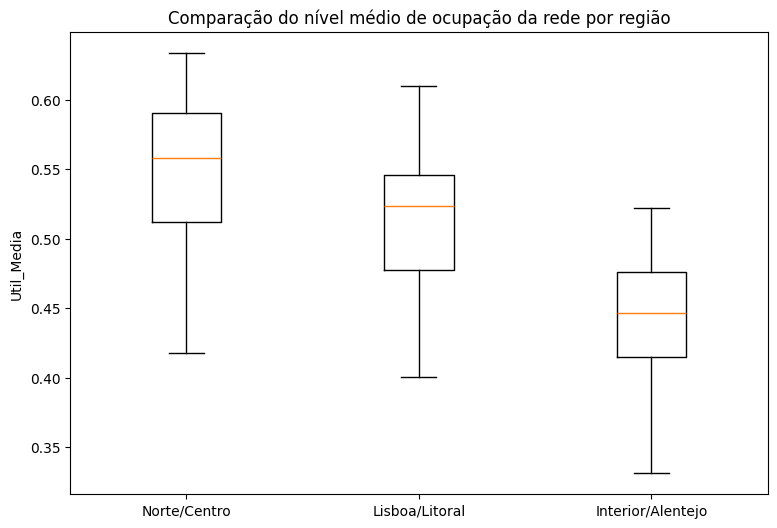


Resultado da ANOVA:
F-statistic: 24.91554564468951
p-value: 5.979667477350417e-09

Conclusão: rejeita-se H0. Existem diferenças significativas entre pelo menos dois grupos.

Teste post-hoc de Tukey:
             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1              group2        meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------------
 Interior/Alentejo   Lisboa/Litoral Sul     0.07 0.0001  0.0335 0.1065   True
 Interior/Alentejo Norte/Centro Litoral    0.106    0.0  0.0694 0.1425   True
Lisboa/Litoral Sul Norte/Centro Litoral    0.036 0.0546 -0.0006 0.0725  False
-----------------------------------------------------------------------------


In [41]:


from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n--- 4.4.3: ANOVA entre regiões ---")

# Trabalhar sobre a base consolidada
df_anova = df_final.copy()

# Criar distrito a partir de CodDistritoConcelho
df_anova["Distrito"] = (df_anova["CodDistritoConcelho"] // 100).map({
    1: "Aveiro",
    2: "Beja",
    3: "Braga",
    6: "Coimbra",
    7: "Évora",
    11: "Lisboa",
    12: "Portalegre",
    13: "Porto",
    15: "Setúbal"
})

# Criar os 3 grupos pedidos no enunciado
grupo1 = df_anova[df_anova["Distrito"].isin(["Porto", "Braga", "Coimbra"])]
grupo2 = df_anova[df_anova["Distrito"].isin(["Lisboa", "Setúbal", "Aveiro"])]
grupo3 = df_anova[df_anova["Distrito"].isin(["Évora", "Beja", "Portalegre"])]

# Verificar se há pelo menos 25 concelhos por grupo
print("Número de concelhos disponíveis por grupo:")
print("Grupo 1:", len(grupo1))
print("Grupo 2:", len(grupo2))
print("Grupo 3:", len(grupo3))

# Amostragem aleatória de 25 concelhos por grupo
amostra1 = grupo1.sample(n=25, random_state=42)["Util_Media"]
amostra2 = grupo2.sample(n=25, random_state=42)["Util_Media"]
amostra3 = grupo3.sample(n=25, random_state=42)["Util_Media"]

# Médias das amostras
print("\nMédias das amostras:")
print("Grupo 1 - Norte/Centro Litoral:", round(amostra1.mean(), 4))
print("Grupo 2 - Lisboa/Litoral Sul:", round(amostra2.mean(), 4))
print("Grupo 3 - Interior/Alentejo:", round(amostra3.mean(), 4))

# Boxplot para apoio visual
plt.figure(figsize=(9, 6))
plt.boxplot(
    [amostra1, amostra2, amostra3],
    labels=["Norte/Centro", "Lisboa/Litoral", "Interior/Alentejo"]
)
plt.title("Comparação do nível médio de ocupação da rede por região")
plt.ylabel("Util_Media")
plt.show()

# ANOVA
anova = f_oneway(amostra1, amostra2, amostra3)

print("\nResultado da ANOVA:")
print("F-statistic:", anova.statistic)
print("p-value:", anova.pvalue)

alpha = 0.05

if anova.pvalue < alpha:
    print("\nConclusão: rejeita-se H0. Existem diferenças significativas entre pelo menos dois grupos.")

    # Post-hoc de Tukey
    dados_tukey = pd.DataFrame({
        "valor": pd.concat([amostra1, amostra2, amostra3], ignore_index=True),
        "grupo": (["Norte/Centro Litoral"] * len(amostra1) +
                  ["Lisboa/Litoral Sul"] * len(amostra2) +
                  ["Interior/Alentejo"] * len(amostra3))
    })

    tukey = pairwise_tukeyhsd(
        endog=dados_tukey["valor"],
        groups=dados_tukey["grupo"],
        alpha=0.05
    )

    print("\nTeste post-hoc de Tukey:")
    print(tukey)

else:
    print("\nConclusão: não se rejeita H0. Não há evidência estatística de diferenças significativas entre os grupos.")

## 4.5 - Correlação e Regressão - Modelo Preditivo

Primeiro, preparou-se o dataset filtrando pelos concelhos que pertencem aos destinos alvo (Aveiro, Porto, Lisboa e Braga)

Além disso, as variáveis usadas refletem:
- **P_IP_Total**: dimensão do consumo de iluminação pública
- **Cap_PTD**: capacidade instalada da rede
- **Rate_Ineficiencia**: proporção de tecnologia ineficiente
- **Util_Media**: variável dependente (nível médio de utilização da rede)

Por fim, removeram-se os valores omissos para garantir uma melhor análise dos dados.


--- 4.5: Preparação dos dados para regressão ---
Dimensão do dataset final: (67, 4)
    P_IP_Total  Cap_PTD  Rate_Ineficiencia  Util_Media
0   910.887701   105715           0.268222    0.477593
1   451.711801    54540           0.062031    0.469948
2   657.071801    55628           0.111928    0.543009
3   585.974400    41884           0.197483    0.527387
4  1055.192001   197485           0.136866    0.475475

--- 4.5: Matriz de Correlação ---
                   P_IP_Total   Cap_PTD  Rate_Ineficiencia  Util_Media
P_IP_Total           1.000000  0.912912           0.363438   -0.359755
Cap_PTD              0.912912  1.000000           0.158621   -0.482402
Rate_Ineficiencia    0.363438  0.158621           1.000000    0.052433
Util_Media          -0.359755 -0.482402           0.052433    1.000000


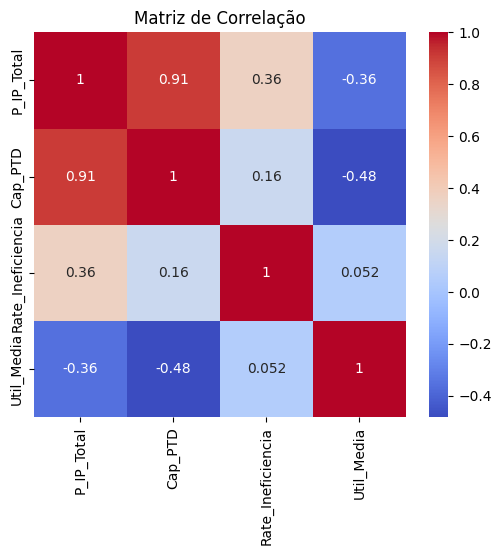

In [42]:
print("\n--- 4.5: Preparação dos dados para regressão ---")

# criar distrito no df_final
df_final["Distrito"] = (df_final["CodDistritoConcelho"] // 100).map({
    1: "Aveiro",
    3: "Braga",
    11: "Lisboa",
    13: "Porto"
})

# filtrar distritos pretendidos
df_modelo = df_final[df_final["Distrito"].isin(["Aveiro", "Porto", "Lisboa", "Braga"])]

# selecionar variáveis relevantes
df_modelo = df_modelo[[
    "P_IP_Total",
    "Cap_PTD",
    "Rate_Ineficiencia",
    "Util_Media"
]]

# remover NaN
df_modelo = df_modelo.dropna()

print("Dimensão do dataset final:", df_modelo.shape)
print(df_modelo.head())

print("\n--- 4.5: Matriz de Correlação ---")

correlacao = df_modelo.corr()

print(correlacao)

import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(correlacao, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

### Comentário sobre a matriz de correlação

A matriz de correlação permite avaliar relações lineares entre variáveis.

Observa-se que:
- A Cap_PTD tende a apresentar relação com a Util_Media, refletindo a estrutura da rede.
- A variável Rate_Ineficiencia apresenta fraca ou inexistente correlação com Util_Media.

Este resultado sugere que a proporção de iluminação ineficiente, por si só, não é um bom preditor do nível de utilização d rede.
Tal pode ser explicado pelo facto de esta variável ser um rácio (proporção), não captando o impacto absoluto em termos de potência.

### 4.5.1 - Regressão linear múltipla

Foi estimado um modelo de regressão linear múltipla com o objetivo de explicar o nível médio de utilização da rede (Util_Media) com base em variáveis explicativas.

In [43]:
# 4.5.1 - Modelo de regressão linear múltipla

import statsmodels.api as sm

print("\n--- 4.5.1: Regressão Linear Múltipla ---")

X = df_modelo[["P_IP_Total", "Cap_PTD", "Rate_Ineficiencia"]]
Y = df_modelo["Util_Media"]

# adicionar constante (β0)
X = sm.add_constant(X)

modelo = sm.OLS(Y, X).fit()

print(modelo.summary())


--- 4.5.1: Regressão Linear Múltipla ---
                            OLS Regression Results                            
Dep. Variable:             Util_Media   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     7.867
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000154
Time:                        15:01:54   Log-Likelihood:                 107.13
No. Observations:                  67   AIC:                            -206.3
Df Residuals:                      63   BIC:                            -197.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

O modelo de regressão linear múltipla apresenta significância estatística global (p < 0.05), sendo capaz de explicar aproximadamente 23.8% da variabilidade do nível médio de ocupação da rede, significando que existem outros fatores importantes na utilização da rede que não estão incluídos no modelo. No entanto, apenas a variável Cap_PTD se revelou estatisticamente significativa (p < 0.05), apresentando uma relação negativa com a variável dependente (coeficiente de -1.99e-07), indicando que maiores capacidades instaladas estão associadas a menores níveis de ocupação da rede.

### 4.5.2 - Verificar as condições sobre os resíduos

#### Normalidade


Teste de normalidade dos resíduos (Shapiro):
p-value: 0.4033270420781676


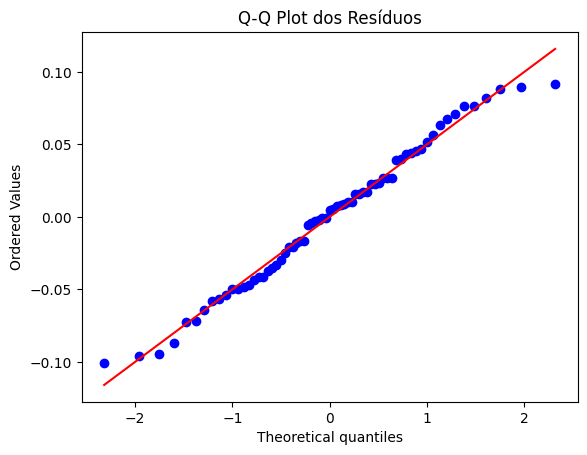

In [44]:
# 4.5.2 - Verificar os resíduos

# Primeiro, verificar a normalidade dos resíduos

residuos = modelo.resid

shapiro_test = stats.shapiro(residuos)

print("\nTeste de normalidade dos resíduos (Shapiro):")
print("p-value:", shapiro_test.pvalue)

stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot dos Resíduos")
plt.show()

Como p-value > 0.05 (0.403 > 0.05) no teste de Shapiro, os resíduos apresentam normalidade.

Através da análise do gráfico, conseguimos verificar essa normalidade, já que os resíduos seguem todos a linha diagonal.

#### Independência

In [45]:
# Segundo, verificr a independência dos resíduos

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(modelo.resid)

print("\nTeste de Durbin-Watson:")
print("Estatística DW:", round(dw, 4))



Teste de Durbin-Watson:
Estatística DW: 2.0156


Valores de referência:
- 1.5 < DW > 2.5 → ausência de autocorrelação (situação ideal)
- DW < 1.5 → autocorrelação positiva
- DW > 2.5 → autocorrelação negativa

O resultado do teste indica ausência de autocorrelação.

#### Homocedasticidade

Para a homocedasticidade se verificar, deve haver simetria relativamente à reta y = 0 e não deve existir tendência

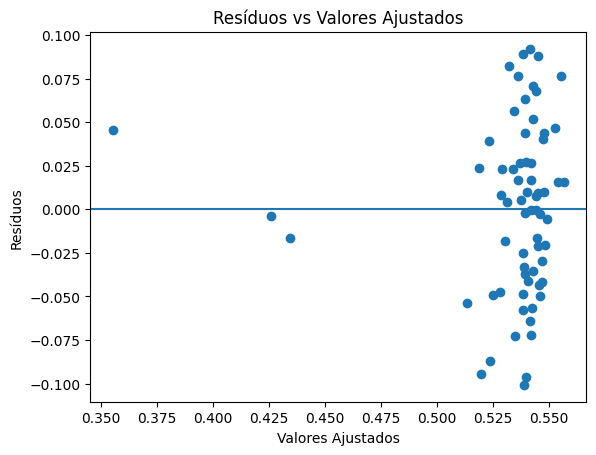

In [46]:
# Terceiro, verificar a homocedasticidade dos resíduos

valores_ajustados = modelo.fittedvalues

plt.scatter(valores_ajustados, residuos)
plt.axhline(y=0)
plt.xlabel("Valores Ajustados")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Valores Ajustados")
plt.show()

NÃO PERCEBI COMO SE INTERPRETA ISTO, VER MELHOR!!

### 4.5.3 - Multicolinearidade

In [47]:
# 4.5.3 - Verificar multicolinearidade

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n--- 4.5.3: VIF ---")

X_vif = X.copy()

vif_data = pd.DataFrame()
vif_data["Variável"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)


--- 4.5.3: VIF ---
            Variável       VIF
0              const  2.345480
1         P_IP_Total  8.506362
2            Cap_PTD  7.573334
3  Rate_Ineficiencia  1.453667
